In [7]:
%reload_ext autoreload
%autoreload 2

import tools.io_tools as io_tools
import tools.processing_tools as processing_tools
import tools.frap_tools as frap_tools
from matplotlib import pyplot as plt
import pandas as pd
import os

import seaborn as sns 

input_folder_paths = ["D:\\Projects\\Shannon\\FRAP analysis\\images\\20250115_MeCP2_FRAP_processed\\WT",
                      "D:\\Projects\\Shannon\\FRAP analysis\\images\\20250115_MeCP2_FRAP_processed\\MUT",
                      "D:\\Projects\\Shannon\\FRAP analysis\\images\\20250115_MeCP2_FRAP_processed\\MUT200"]

input_folder_paths = ["D:\\Projects\\Shannon\FRAP analysis\\images\\CSV\\20250626_WGA_iPSC_Tatsuya_csv\\csv\\WT",
                      "D:\\Projects\\Shannon\FRAP analysis\\images\\CSV\\20250626_WGA_iPSC_Tatsuya_csv\\csv\\R306C",
                    "D:\\Projects\\Shannon\FRAP analysis\\images\\CSV\\20250626_WGA_iPSC_Tatsuya_csv\\csv\\R306C_NAC"]

input_folder_paths = ["D:\\Projects\\Shannon\FRAP analysis\\images\\CSV\\20250910_WGA_iPSC_Rett_SUR\\R306C",
                      "D:\\Projects\\Shannon\FRAP analysis\\images\\CSV\\20250910_WGA_iPSC_Rett_SUR\\R306C_NAC",
                      "D:\\Projects\\Shannon\FRAP analysis\\images\\CSV\\20250910_WGA_iPSC_Rett_SUR\\WT",
                      "D:\\Projects\\Shannon\FRAP analysis\\images\\CSV\\20250910_WGA_iPSC_Rett_SUR\\WT_NAC"]

#input_folder_paths = ["D:\\Projects\\Shannon\\FRAP analysis\\images\\CSV\\20250808_FRAP_2.5D_organoids_WGA_1to2000dil"]
#iput_folder_paths = ["D:\Projects\Shannon\FRAP analysis\images\CSV"]

do_whole_cell = False
exp_fitting_order = 1


output_path = "D:\\Projects\\Shannon\\FRAP analysis\\images\\"

roiData = []
frap_experiment = []
wt_preview = []

for idx,folderPath in enumerate(input_folder_paths):

    #print('Processing files from directory: ' + folderPath)
    dataset_roiData, dataset_frap_experiment, wt_preview = frap_tools.process_FRAP_folder(folderPath, wcell_corr= do_whole_cell, fitting_exp = exp_fitting_order)
    print(os.path.dirname(folderPath))
    dataset_roiData.insert(loc=0, column = 'folder', value = os.path.basename(folderPath))
    dataset_frap_experiment.insert(loc=0, column = 'folder', value = os.path.basename(folderPath))
    roiData.append(dataset_roiData)
    frap_experiment.append(dataset_frap_experiment)
    io_tools.saveResults(os.path.join(output_path,os.path.basename(folderPath)), dataset_roiData, dataset_frap_experiment)


#frap_experiment = pd.concat(frap_experiment, ignore_index = True)

#wt_dataset_roiData, wt_dataset_frap_experiment, wt_preview = frap_tools.process_FRAP_folder(wtPath, wcell_corr= True, fitting_exp = 1)
#mut_dataset_roiData, mut_dataset_frap_experiment, mut_preview = frap_tools.process_FRAP_folder(mutPath, wcell_corr= True, fitting_exp = 1)


#io_tools.saveResults(wtPath, wt_dataset_roiData, wt_dataset_frap_experiment)
#io_tools.saveResults(mutPath, mut_dataset_roiData, mut_dataset_frap_experiment)

#fig, axes = plt.subplots(2, figsize=(12, 16)) 

#sns.lineplot(ax = axes[0], data =wt_dataset_roiData, x= 'timestamp_frap_r', y = 'frap_norm_r', hue = 'dish' )
#sns.lineplot(ax = axes[1], data =mut_dataset_roiData, x= 'timestamp_frap_r', y = 'frap_norm_r', hue = 'dish' )

Processing files from directory: D:\Projects\Shannon\FRAP analysis\images\CSV\20250910_WGA_iPSC_Rett_SUR\R306C

[processFiles] processing file 1 of 7
[processFiles] Filename = dish3_R306C_roi10.csv
[parse_filename] Metadata retreived from filename: 
	group = unknown
	dish = 3
	Protein = unknown
	ROI  = 10
[photobleaching_corr] Calculating photobleaching from imaging using control_roi reference region
	using data from frame 5 onwards (0 after roi bleaching)
17.167205191855345
[np.float64(215.99450971207898), 0.1, 0.001]
Fit results:
	offset = 194.39505874087115
	amplitude: 4.076708712014836e-05
	tau: 9.148889817264491
	Fitting error (r2)= -0.012537573453494932
	Fitting goodness (chi2)= 2.966337530705976
Fitting recovery model
Fit results:
	offset = 0.8488417743731349
	amplitude: -0.5272746208408895
	tau: 0.04481992856033026
	Fitting error (r2)= 0.8572471829051389
	Fitting goodness (chi2)= 0.353798629070378

[processFiles] processing file 2 of 7
[processFiles] Filename = dish3_R306C_roi1

KeyError: 'reference_synth'

C:\Users\amarcosv\AppData\Local\Temp\ipykernel_99652\413562402.py:20: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.4, bottom=0.2)


KeyboardInterrupt: 

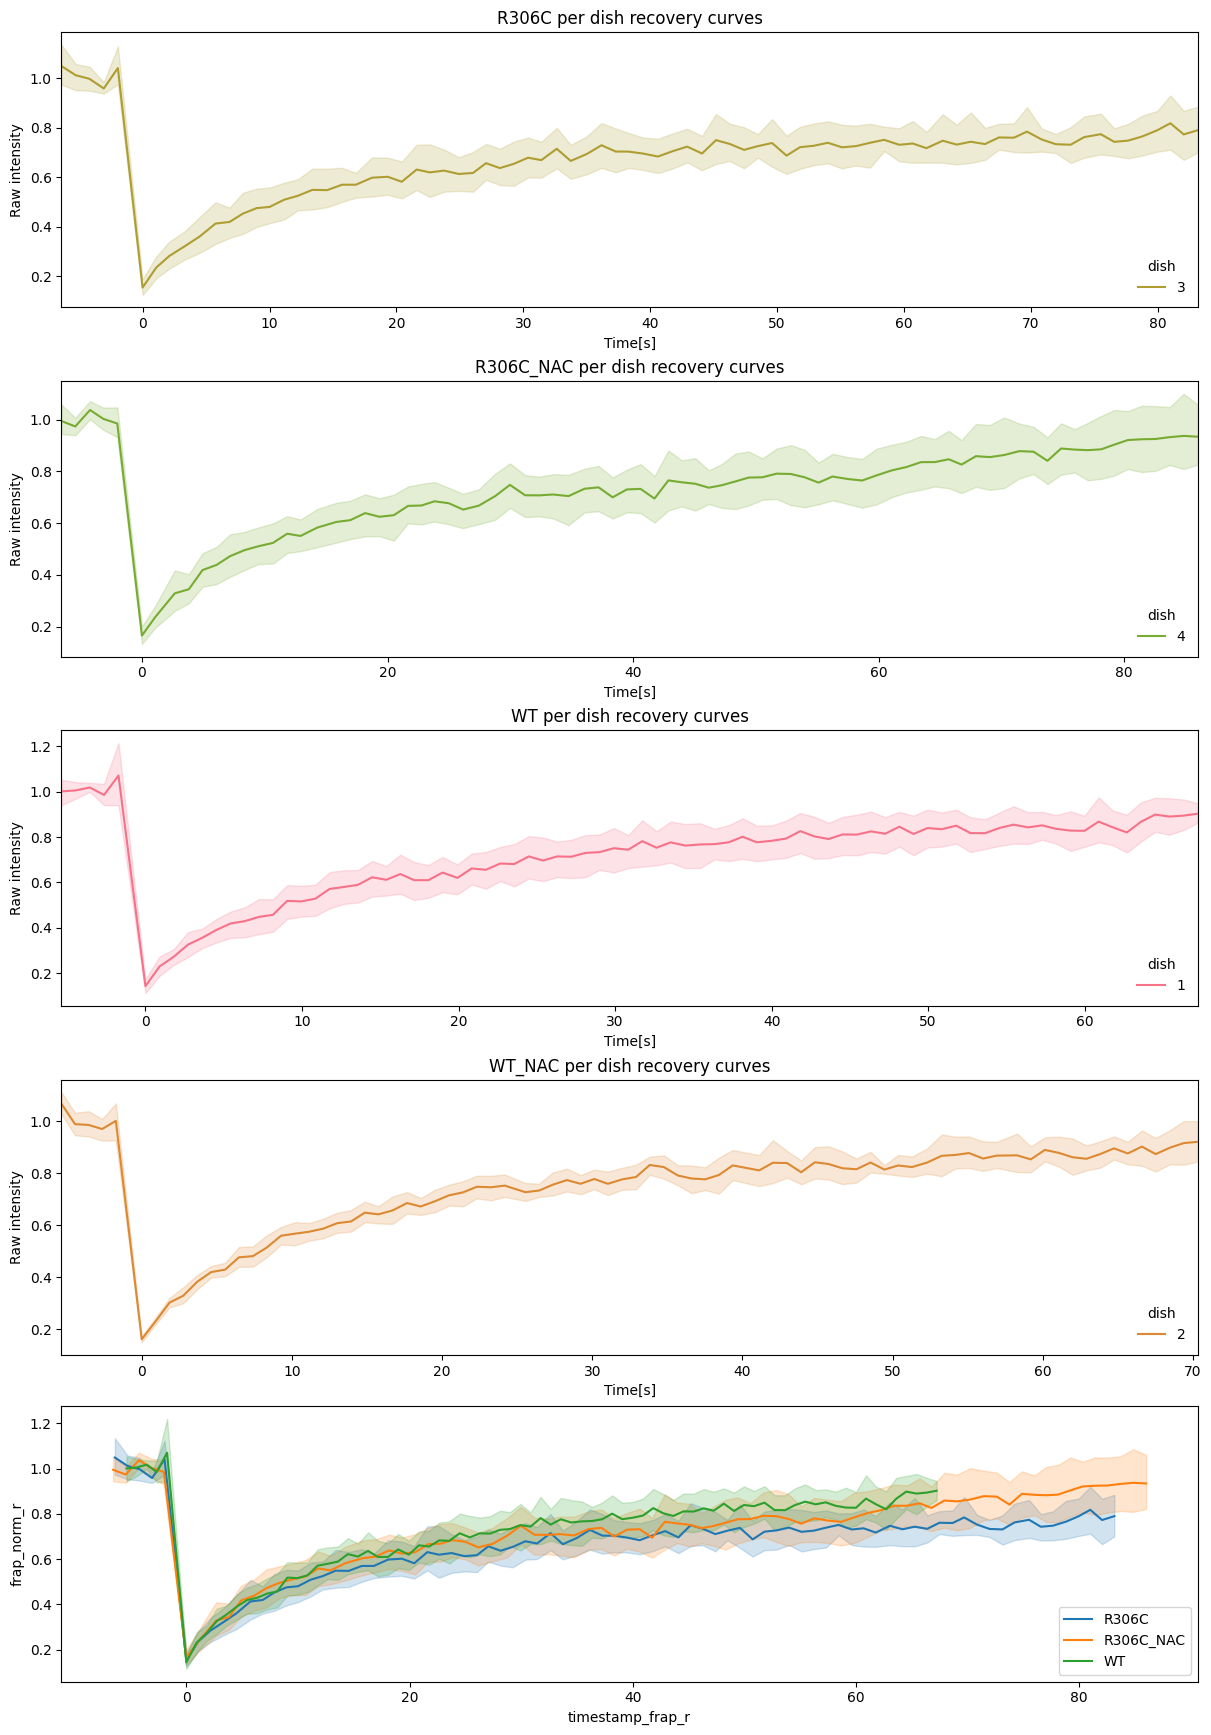

In [6]:
from matplotlib.ticker import FormatStrFormatter

nrows = 6 + 2* len(input_folder_paths)
nd = len(input_folder_paths)
ax = []
#Color palette for multiple groups
palette = sns.color_palette("tab10")
#color palette for dishes
dish_palette = sns.color_palette("husl",10)
dish_palette = {'1': dish_palette[0], '2': dish_palette[1], '3': dish_palette[2],
                '4': dish_palette[3], '5': dish_palette[4], '6': dish_palette[5],
                '7': dish_palette[6], '8': dish_palette[7], '9': dish_palette[8], 
                '10': dish_palette[9]}



#import matplotlib.gridspec as gridspec
fig = plt.figure(constrained_layout=True, figsize=(12, nrows*3))
spec = fig.add_gridspec(nrows, 4)
plt.subplots_adjust(hspace=0.4, bottom=0.2)

# PLOT raw data per folder and dish
for i in range(nd):
    ax = fig.add_subplot(spec[i, :])
    sns.lineplot(ax = ax, data =roiData[i], x= 'timestamp_frap_r', y = 'frap_norm_r', hue = 'dish', palette=dish_palette )
    ax.set_title(os.path.basename(input_folder_paths[i]) + ' per dish recovery curves')
    ax.set_ylabel('Raw intensity')
    ax.set_xlabel('Time[s]')
    ax.margins(x=0)
    sns.move_legend(ax, "lower right", frameon=False)
#ax.legend(title = 'dish',frameon=False)


# PLOT raw data all together
ax = fig.add_subplot(spec[nd, :])
for i in range(nd):
        sns.lineplot(ax = ax, data =roiData[i], x= 'timestamp_frap_r', y = 'frap_norm_r',  label = os.path.basename(input_folder_paths[i]) , color=palette[i])
ax.set_title(os.path.basename(input_folder_paths[i]) + ' per dish recovery curves')
ax.set_ylabel('Raw intensity')
ax.set_xlabel('Time[s]')
ax.margins(x=0)
sns.move_legend(ax, "lower right", frameon=False)

# PLOT Boxplots for mobile fraction and tau1/2
ax = fig.add_subplot(spec[nd+1: nd+3,0:2])
for i in range(nd):
    sns.boxplot(ax = ax, data = frap_experiment[i], x="folder", y="mob", label = os.path.basename(input_folder_paths[i]), color=palette[i])
ax.set_title('Mobile fraction')
ax.set_ylabel('Mobile fraction')
ax.set_xlabel(None)
#ax.set(ylim=( 0,1.3))
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1),frameon=False)
mob_ax = ax

ax = fig.add_subplot(spec[nd+1:nd+3,2::])
for i in range(nd):
    sns.boxplot(ax = ax, data = frap_experiment[i], x="folder", y="half_max", label = os.path.basename(input_folder_paths[i]), color=palette[i])
ax.set_title('Recovery half max ')
ax.set_ylabel(r'$\tau^{1/2}$ [s]')
ax.set_xlabel(None)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1),frameon=False)
#ax.set(ylim=( 0,4))



# PLOT Mobile fraction per dish
ax = fig.add_subplot(spec[nd+3, :])
for i in range(nd):
    #Fix bug with seaborn where if there is a single dish the dodge parameter needs to be set to false for pointplot or will crash
    n_dish=len(frap_experiment[i]['dish'].unique())    
    if n_dish == 1: dodge_param = False
    else: dodge_param = .4

    sns.stripplot(ax = ax, data = frap_experiment[i], x="folder", y="mob", hue = "dish",
        dodge=True, alpha=.2, legend=False, palette = dish_palette)
    sns.pointplot(ax = ax, data = frap_experiment[i], x="folder", y="mob", hue = "dish", 
        dodge=dodge_param, linestyle="none", errorbar=None, marker="_", markersize=20, markeredgewidth=3,  palette=dish_palette)
    
ax.set_title('Mobile fraction per dish')
ax.set_ylabel('Mobile fraction')
ax.set_xlabel(None)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1),frameon=False)
#plt.show()


# PLOT tau 1/2  per dish
ax = fig.add_subplot(spec[nd+4, :])
for i in range(nd):
    #Fix bug with seaborn where if there is a single dish the dodge parameter needs to be set to false for pointplot or will crash
    n_dish=len(frap_experiment[i]['dish'].unique())    
    if n_dish == 1: dodge_param = False
    else: dodge_param = .4
    
    sns.stripplot(ax = ax, data = frap_experiment[i], x="folder", y="half_max", hue = "dish",
        dodge=True, alpha=.2, legend=False, palette="Set2" )
    
    sns.pointplot(ax = ax, data = frap_experiment[i], x="folder", y="half_max", hue = "dish", 
    dodge=dodge_param, linestyle="none", errorbar=None, marker="_", markersize=20, markeredgewidth=3, palette="Set2")

ax.set_title('Recovery half max per dish')
ax.set_ylabel(r'$\tau^{1/2}$ [s]')
ax.set_xlabel(None)    
ax.legend(title='dish')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1),frameon=False)


# PLOT FRAP recovery full scale per group
ax = fig.add_subplot(spec[nd+5 , :])
for i in range(nd):
    sns.lineplot(ax = ax, data =roiData[i], x= 'timestamp_frap_r', y = 'frap_fullscale_norm_r', label = os.path.basename(input_folder_paths[i]), errorbar = 'se')
    #sns.lineplot(ax = ax, data =roiData[i], x= 'timestamp_frap_r', y = 'frap_fullscale_norm_r', label = os.path.basename(input_folder_paths[i]) ,errorbar = 'se')
ax.set_title('Full scale FRAP recovery')
ax.set_ylabel('Full scale Normalized intensity')
ax.set_xlabel('Time[s]')
ax.margins(x=0)
sns.move_legend(ax, "lower right", frameon=False)


# PLOT FRAP recovery full scale per group and dish
for i in range(nd):
    ax = fig.add_subplot(spec[nd+6 + i, :])
    sns.scatterplot(ax = ax, data =roiData[i][roiData[i]['timepoint_frap']>=0], x= 'timestamp_frap_r', y = 'frap_norm_r',
                alpha = 0.1, color=palette[i], legend = None)
    sns.lineplot(ax = ax, data =roiData[i][roiData[i]['timepoint_frap']>=0], x= 'timestamp_frap_r', y = 'frap_norm_r', label = os.path.basename(input_folder_paths[i]),
                errorbar = 'sd', err_style = 'bars', color=palette[i])
    ax.set_title('Full scale recovery - ' + os.path.basename(input_folder_paths[i]))
    ax.set_ylabel('Full scale Normalized intensity')
    ax.set_xlabel('Time[s]')
    sns.move_legend(ax, "lower right", frameon=False)


basenames =  [os.path.basename(f) for f in input_folder_paths]
outputName = "_".join(basenames)

fig.savefig(os.path.join(output_path,outputName + 'frap_results.pdf'), bbox_inches='tight', dpi=300)


"""ax1 = fig.add_subplot(spec[1, :])
sns.lineplot(ax = ax1, data =mut_dataset_roiData, x= 'timestamp_frap_r', y = 'frap_norm_r', hue = 'dish', palette="Set1" )
ax1.set_title('MUT per dish recovery curves')
ax1.set_ylabel('Normalized to pre-bleach intensity')
ax1.set_xlabel('Time[s]')

ax2 = fig.add_subplot(spec[2, :])
sns.lineplot(ax = ax2, data =wt_dataset_roiData, x= 'timestamp_frap_r', y = 'frap_norm_r', label = 'WT')
sns.lineplot(ax = ax2, data =mut_dataset_roiData, x= 'timestamp_frap_r', y = 'frap_norm_r', label = 'MUT' )
ax2.set_ylabel('Normalized to pre-bleach intensity')
ax2.set_xlabel('Time[s]')
ax2.set_title('WT vs MUT ensemble')
#axes[2].legend(['WT','Mut'])
if wt_dataset_frap_experiment['recovery_model'][0].item()==1:
    
    ax3_0 = fig.add_subplot(spec[3, :-1])
    ax3_1 = fig.add_subplot(spec[3, -1])
    sns.stripplot(ax = ax3_0, data = wt_dataset_frap_experiment, x="group", y="half_max", hue = "dish",
        dodge=True, alpha=.2, legend=False, palette="Set2" )
    sns.pointplot(ax = ax3_0, data = wt_dataset_frap_experiment, x="group", y="half_max", hue = "dish", 
    dodge=.4, linestyle="none", errorbar=None, marker="_", markersize=20, markeredgewidth=3, palette="Set2" )
    sns.stripplot(ax = ax3_0, data = mut_dataset_frap_experiment, x="group", y="half_max", hue = "dish",
        dodge=True, alpha=.2, legend=False, palette="Set1" )
    sns.pointplot(ax = ax3_0, data = mut_dataset_frap_experiment, x="group", y="half_max", hue = "dish", 
    dodge=.4, linestyle="none", errorbar=None, marker="_", markersize=20, markeredgewidth=3, palette="Set1" )
    ax3_0.set_title('Recovery half max')
    sns.boxplot(ax = ax3_1, data = wt_dataset_frap_experiment, x="group", y="half_max")
    sns.boxplot(ax = ax3_1, data = mut_dataset_frap_experiment, x="group", y="half_max")
    ax3_1.set_title('Recovery half max ')
    ax3_1.set(ylim=( 0,4))

else:
    ax3_0 = fig.add_subplot(spec[3, 0])
    ax3_1 = fig.add_subplot(spec[3, 1])
    ax3_2 = fig.add_subplot(spec[3, -1])   
    sns.stripplot(ax = ax3_0, data = wt_dataset_frap_experiment, x="group", y="half_max_slow", hue = "dish",
        dodge=True, alpha=.2, legend=False, palette = sns.color_palette())
    sns.pointplot(ax = ax3_0, data = wt_dataset_frap_experiment, x="group", y="half_max_slow", hue = "dish", 
    dodge=.4, linestyle="none", errorbar=None, marker="_", markersize=20, markeredgewidth=3, palette = sns.color_palette())
    sns.stripplot(ax = ax3_0, data = mut_dataset_frap_experiment, x="group", y="half_max_slow", hue = "dish",
        dodge=True, alpha=.2, legend=False, palette = sns.color_palette())
    sns.pointplot(ax = ax3_0, data = mut_dataset_frap_experiment, x="group", y="half_max_slow", hue = "dish", 
    dodge=.4, linestyle="none", errorbar=None, marker="_", markersize=20, markeredgewidth=3, palette = sns.color_palette())
    ax3_0.set_title('Slow recovery half max')
    ax3_0.set(ylim=( 0,1.5))
    ax3_0.get_legend().remove()
    
    sns.stripplot(ax = ax3_1, data = wt_dataset_frap_experiment, x="group", y="half_max_fast", hue = "dish",
        dodge=True, alpha=.2, legend=False, palette = sns.color_palette())
    sns.pointplot(ax = ax3_1, data = wt_dataset_frap_experiment, x="group", y="half_max_fast", hue = "dish", 
    dodge=.4, linestyle="none", errorbar=None, marker="_", markersize=20, markeredgewidth=3, palette = sns.color_palette())
    sns.stripplot(ax = ax3_1, data = mut_dataset_frap_experiment, x="group", y="half_max_fast", hue = "dish",
        dodge=True, alpha=.2, legend=False, palette = sns.color_palette())
    sns.pointplot(ax = ax3_1, data = mut_dataset_frap_experiment, x="group", y="half_max_fast", hue = "dish", 
    dodge=.4, linestyle="none", errorbar=None, marker="_", markersize=20, markeredgewidth=3, palette = sns.color_palette())
    ax3_1.set_title('Fast recovery half max')
    ax3_1.set(ylim=( 0,10))
    ax3_1.get_legend().remove()

    sns.scatterplot(ax = ax3_2, data = wt_dataset_frap_experiment, x="half_max_slow", y="half_max_fast", hue = "dish", style = 'group',
                    palette = sns.color_palette("Blues"))
    sns.scatterplot(ax = ax3_2, data = mut_dataset_frap_experiment, x="half_max_slow", y="half_max_fast", hue = "dish", style = 'group'
                    , palette = sns.color_palette("Reds"))
    ax3_2.set_title('Distribution of half max')
    ax3_2.set(xlim=( 0,1.5))
    ax3_2.set(ylim=( 0,10))

ax4_0 = fig.add_subplot(spec[4, :-1])
ax4_1 = fig.add_subplot(spec[4, -1])
sns.stripplot(ax = ax4_0, data = wt_dataset_frap_experiment, x="group", y="mob", hue = "dish",
    dodge=True, alpha=.2, legend=False, palette = sns.color_palette())
sns.pointplot(ax = ax4_0, data = wt_dataset_frap_experiment, x="group", y="mob", hue = "dish", 
dodge=.4, linestyle="none", errorbar=None, marker="_", markersize=20, markeredgewidth=3, palette = sns.color_palette())
sns.stripplot(ax = ax4_0, data = mut_dataset_frap_experiment, x="group", y="mob", hue = "dish",
    dodge=True, alpha=.2, legend=False, palette = sns.color_palette())
sns.pointplot(ax = ax4_0, data = mut_dataset_frap_experiment, x="group", y="mob", hue = "dish", 
dodge=.4, linestyle="none", errorbar=None, marker="_", markersize=20, markeredgewidth=3, palette = sns.color_palette())
ax4_0.set_title('Mobile fraction')
sns.boxplot(ax = ax4_1, data = wt_dataset_frap_experiment, x="group", y="mob")
sns.boxplot(ax = ax4_1, data = mut_dataset_frap_experiment, x="group", y="mob")
ax4_1.set_title('Mobile fraction')
ax4_1.set(ylim=( 0,1.3))


ax5 = fig.add_subplot(spec[5, :])
sns.lineplot(ax = ax5, data =wt_dataset_roiData, x= 'timestamp_frap_r', y = 'frap_fullscale_norm_r', label = 'WT',errorbar = 'se')
sns.lineplot(ax = ax5, data =mut_dataset_roiData, x= 'timestamp_frap_r', y = 'frap_fullscale_norm_r', label = 'MUT' ,errorbar = 'se')
ax5.set_ylabel('Full scale Normalized  intensity')
ax5.set_xlabel('Time[s]')
ax5.set_title('WT vs MUT ensemble - Full scale')

ax6 = fig.add_subplot(spec[6, :])
sns.scatterplot(ax = ax6, data =wt_dataset_roiData[wt_dataset_roiData['timepoint_frap']>=0], x= 'timestamp_frap_r', y = 'frap_norm_r', label = 'WT',
              alpha = 0.1)

#timestamps = wt_dataset_roiData[wt_dataset_roiData['timepoint_frap']>=0].groupby('timepoint')['timestamp_frap'].mean()   
#y = wt_dataset_roiData[wt_dataset_roiData['timepoint_frap']>=0].groupby('timepoint')['frap_norm_r'].mean()
#y_std = wt_dataset_roiData[wt_dataset_roiData['timepoint_frap']>=0].groupby('timepoint')['frap_norm_r'].std()
    #dataset_roiData['timestamp_frap_r'] = timestamps
#ax6.errorbar(timestamps, y, yerr = y_std)
sns.lineplot(ax = ax6, data =wt_dataset_roiData[wt_dataset_roiData['timepoint_frap']>=0], x= 'timestamp_frap_r', y = 'frap_norm_r', label = 'WT',
              errorbar = 'sd', err_style = 'bars')

#sns.lineplot(ax = ax6, data =mut_dataset_roiData, x= 'timestamp_frap_r', y = 'frap_fullscale_norm_r', label = 'MUT' )
ax6.set_ylabel('Full scale Normalized  intensity')
ax6.set_xlabel('Time[s]')
ax6.set_title('WT vs MUT ensemble - Full scale')
ax7 = fig.add_subplot(spec[7::, :])
sns.scatterplot(ax = ax7, data =mut_dataset_roiData[mut_dataset_roiData['timepoint_frap']>=0], x= 'timestamp_frap_r', y = 'frap_norm_r', label = 'MUT',
              alpha = 0.1, color='tab:orange')
sns.lineplot(ax = ax7, data =mut_dataset_roiData[mut_dataset_roiData['timepoint_frap']>=0], x= 'timestamp_frap_r', y = 'frap_norm_r', label = 'MUT',
              errorbar = 'sd', err_style = 'bars', color='tab:orange')

#sns.lineplot(ax = ax6, data =mut_dataset_roiData, x= 'timestamp_frap_r', y = 'frap_fullscale_norm_r', label = 'MUT' )
ax7.set_ylabel('Full scale Normalized  intensity')
ax7.set_xlabel('Time[s]')
ax7.set_title('WT vs MUT ensemble - Full scale')
#ax6.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
"""

In [21]:
           
from statannotations.Annotator import Annotator

from itertools import combinations

import scipy.stats as stats
import numpy as np
from scikit_posthocs import posthoc_dunn



basenames =  [os.path.basename(f) for f in input_folder_paths]

basenames_id = range(len(basenames))

pairs =  list(combinations(basenames, 2))
pairs_id =  list(combinations(basenames_id, 2))





print('Statistical analysis of Mobile Fraction:')
data_g = []
p_val_shapiro = np.zeros(len(basenames))
print('\nTest of normality for all groups:')
#Run Shapiro-Wilk and Levene to evaluate if data follows normal distribution and has equal variances
for i,folder in enumerate(basenames):

    data= frap_experiment[i]['mob'].to_numpy()   
    stat, p = stats.shapiro(data)
    data_g.append(data.copy())

    p_val_shapiro[i] =p
    
    print(f"[{folder}] Shapiro-Wilk Statistic: {stat}, p-value: {p}")

stat, p_val_levene = stats.levene(*data_g)

print(f" Levene Statistic: {stat}, p-value: {p_val_levene}")



if(all(p_val_shapiro>=0.05) & (p_val_levene>=0.05)):
    print("\nData follow a normal distribution")
    print("Running ANOVA:")

    # First we do a oneway ANOVA as implemented in SciPy
    stat, p_val_anova = stats.f_oneway(*data_g)
    print(f"One way Anova: {stat}, p-value: {p_val_anova}") 
    if len(basenames_id)>2:
        if p_val_anova <0.05:
            #Run posthoc tests
            tukey_df = stats.tukey_hsd(*data_g)
            print("Running post-hoc tests:")
            print(tukey_df)
            print(tukey_df.pvalue)
        else:
            print("No statistical significance found in ANOVA. No need for post hoc tests")
            
else:
    print("\nData does not follow a normal distribution. Running non parametric testing")
    print("Running Kruskal-Wallis:")
    stat, p_val = stats.kruskal(*data_g)
    print(f"Kruskal-Wallis: {stat}, p-value: {p_val}")
    if len(basenames_id)>2:
        if p_val <0.05:
            #Run posthoc tests
            p_values_dunn = posthoc_dunn(*data_g, p_adjust='bonferroni')
            print("Running post-hoc tests:")
            print(p_values_dunn)            
        else:
            print("No statistical significance found in Kruskal-Wallis. No need for post hoc tests")



print('\nStatistical analysis of Recovery Half Max:')
data_g = []
p_val_shapiro = np.zeros(len(basenames))
print('\nTest of normality for all groups:')
#Run Shapiro-Wilk and Levene to evaluate if data follows normal distribution and has equal variances
for i,folder in enumerate(basenames):

    data= frap_experiment[i]['half_max'] 
    stat, p = stats.shapiro(data)
    data_g.append(data.copy())

    p_val_shapiro[i] =p
    
    print(f"[{folder}] Shapiro-Wilk Statistic: {stat}, p-value: {p}")

stat, p_val_levene = stats.levene(*data_g)

print(f" Levene Statistic: {stat}, p-value: {p_val_levene}")



if(all(p_val_shapiro>=0.05) & (p_val_levene>=0.05)):
    print("\nData follow a normal distribution")
    print("Running ANOVA:")

    # First we do a oneway ANOVA as implemented in SciPy
    stat, p_val_anova = stats.f_oneway(*data_g)
    print(f"One way Anova: {stat}, p-value: {p_val_anova}")

    if len(basenames_id)>2:
        if p_val_anova <0.05:
            #Run posthoc tests
            tukey_df = stats.tukey_hsd(*data_g)
            print("Running post-hoc tests:")
            print('Groups compared: ', basenames)
            print(tukey_df)
            print(tukey_df.pvalue)
        else:
            print("No statistical significance found in ANOVA. No need for post hoc tests")
            
else:
    print("\nData does not follow a normal distribution. Running non parametric testing")
    print("Running Kruskal-Wallis:")
    stat, p_val = stats.kruskal(*data_g)
    print(f"Kruskal-Wallis: {stat}, p-value: {p_val}")
    if len(basenames_id)>2:
        if p_val <0.05:
            #Run posthoc tests
            p_values_dunn = posthoc_dunn(data_g, p_adjust='bonferroni')
            print("Running post-hoc tests:")
            print('Groups compared: ', basenames)
            print(p_values_dunn)            
        else:
            print("No statistical significance found in Kruskal-Wallis. No need for post hoc tests")            
    

'''
stat_data = pd.concat(frap_experiment) 

annot = Annotator(
    mob_ax,
    data=stat_data,
    x="folder",
    y="mob",
    pairs = pairs)
annot.configure(test="t-test_ind",
    comparisons_correction="bonferroni",
    text_format="star",
    loc="outside")
annot.apply_test()

ax_annot,test_results = annot.annotate()



print(groups_u)
print(datasets_u)

for r_dilation in datasets_u:
    for g in groups_u:
      data=(results[(results['group'] == g) & (results['dataset'] == r_dilation)]['memb_to_cyto_ratio']).to_numpy()
      data = data[~np.isnan(data)]
      stat, p = stats.shapiro(data)
      print(f"[{r_dilation}, {g}] Shapiro-Wilk Statistic: {stat}, p-value: {p}")

ax = sns.violinplot(x="dataset", y="memb_to_cyto_ratio",
             palette=["m", "g"],
            data=results, hue = 'group')            

plt.xlabel('Dataset')        
plt.ylabel('Membrane to cytoplasm intensity ratio')   


pairs = [(('actin','gcl'),('actin','gclHET')),
         (('myosin','gcl'),('myosin','gclHET')),
         (('PIP2','gcl'),('PIP2','gclHET')),
         (('PIP3','gcl'),('PIP3','gclHET'))
         ]

annot = Annotator(
    ax,
    data=results,
    x="dataset",
    y="memb_to_cyto_ratio",
    hue="group",   
    pairs = pairs)
annot.configure(test="Mann-Whitney",
    text_format="star",
    loc="outside")

annot.apply_test()
ax,test_results = annot.annotate()
'''

Statistical analysis of Mobile Fraction:

Test of normality for all groups:
[WT] Shapiro-Wilk Statistic: 0.9278631077799346, p-value: 0.4612681467457124
[R306C] Shapiro-Wilk Statistic: 0.9195255375357866, p-value: 0.35301468890017007
[R306C_NAC] Shapiro-Wilk Statistic: 0.8307990430565836, p-value: 0.08142584461219812
 Levene Statistic: 0.7547103257956458, p-value: 0.48143769337198744

Data follow a normal distribution
Running ANOVA:
One way Anova: 3.0481831340846663, p-value: 0.06694596889553357
No statistical significance found in ANOVA. No need for post hoc tests

Statistical analysis of Recovery Half Max:

Test of normality for all groups:
[WT] Shapiro-Wilk Statistic: 0.9427336606989433, p-value: 0.6109516989419214
[R306C] Shapiro-Wilk Statistic: 0.8294310514286607, p-value: 0.03293690632703665
[R306C_NAC] Shapiro-Wilk Statistic: 0.9581946789123903, p-value: 0.8031049128081015
 Levene Statistic: 0.9838218289910998, p-value: 0.38907041147932375

Data does not follow a normal distribu

'\nstat_data = pd.concat(frap_experiment) \n\nannot = Annotator(\n    mob_ax,\n    data=stat_data,\n    x="folder",\n    y="mob",\n    pairs = pairs)\nannot.configure(test="t-test_ind",\n    comparisons_correction="bonferroni",\n    text_format="star",\n    loc="outside")\nannot.apply_test()\n\nax_annot,test_results = annot.annotate()\n\n\n\nprint(groups_u)\nprint(datasets_u)\n\nfor r_dilation in datasets_u:\n    for g in groups_u:\n      data=(results[(results[\'group\'] == g) & (results[\'dataset\'] == r_dilation)][\'memb_to_cyto_ratio\']).to_numpy()\n      data = data[~np.isnan(data)]\n      stat, p = stats.shapiro(data)\n      print(f"[{r_dilation}, {g}] Shapiro-Wilk Statistic: {stat}, p-value: {p}")\n\nax = sns.violinplot(x="dataset", y="memb_to_cyto_ratio",\n             palette=["m", "g"],\n            data=results, hue = \'group\')            \n\nplt.xlabel(\'Dataset\')        \nplt.ylabel(\'Membrane to cytoplasm intensity ratio\')   \n\n\npairs = [((\'actin\',\'gcl\'),(\'actin

In [20]:
import numpy as np
np.mean(dataset_frap_experiment['SNR'])

np.float64(20.28562472913397)